In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
library(tidyverse)

# import interpolation functions
source('data/interpolateData.r')

# Read phytoplankton count data
ds <- read.csv("data/BCO-DMO/phytoplankton.csv")  #, na.strings=c("nd","?"))

# Fix date, Aphia ID and depth columns
ds$date = parse_date_time(ds$Datetime_UTC, orders="%Y-%m-%d[.]H:M", tz='UTC')
ds$d_1m   <- as.numeric(ds$d_1m)
ds$d_7m   <- as.numeric(ds$d_7m)
ds$d_15m  <- as.numeric(ds$d_15m)
ds$d_25m  <- as.numeric(ds$d_25m)
ds$d_35m  <- as.numeric(ds$d_35m)
ds$d_55m  <- as.numeric(ds$d_55m)
ds$d_75m  <- as.numeric(ds$d_75m)
ds$d_100m <- as.numeric(ds$d_100m)
ds$AphiaID = as.integer(ds$AphiaID)

# read annotated and corrected pyhytoplankton data (table with manually corrected names and IDs)
occurrence_corrected <- read.csv("data/processed/corrected_phyto_names_and_ids.csv", stringsAsFactor=FALSE)

# trim dataframe to relevant columns
AphiaIDcorrected <- data.frame("AphiaID" = as.integer(occurrence_corrected$AphiaID), 
                               "TaxonRank"=as.character(occurrence_corrected$IdentifiedRank),
                               "CorrectedAphiaID"=as.integer(occurrence_corrected$CorrectedAphiaID), 
                               "SpeciesNameCleaned"=occurrence_corrected$SpeciesNameCleaned, 
                               "ScientificName_corrected"=occurrence_corrected$ScientificName_corrected,
                               "FuncGroup"=occurrence_corrected$FuncGroup,
                               "Genus"=occurrence_corrected$Genus, stringsAsFactors=FALSE)


# Filter out duplicates
AphiaIDcorrected_rmdp <- AphiaIDcorrected %>% distinct(AphiaID, ScientificName_corrected, .keep_all = TRUE)

AphiaIDcorrected_rmdp <- AphiaIDcorrected %>% distinct(AphiaID, SpeciesNameCleaned, .keep_all = TRUE)

# Merge the original data and the corrected by species name and Aphia ID
ds_phytoMergedCorrected <- merge(ds, AphiaIDcorrected_rmdp, by=c("AphiaID", "SpeciesNameCleaned"), all=TRUE)

# add nanoflagellate data with placeholder AphiaID:
ds_phytoMergedCorrected[ds_phytoMergedCorrected$SpeciesNameCleaned=="nanoflagellates",]$AphiaID <- 1

# replace Aphia IDs from original dataset with corrected annotated IDs, then remove NA Aphia IDs (only identified samples)
ds_FG <- ds_phytoMergedCorrected %>% mutate(AphiaID = coalesce(AphiaID, CorrectedAphiaID)) %>% drop_na(AphiaID)

# extract metadata of unique identified units for later merging with interpolated counts via Aphia ID:
ds_FG_uniqueInfo <- ds_FG  %>% group_by(AphiaID) %>% 
  summarize(TaxonRank=first(TaxonRank, na_rm = TRUE), FuncGroup=first(FuncGroup, na_rm = TRUE), 
            Genus=first(Genus, na_rm = TRUE), ScientificName_corrected=first(ScientificName_corrected, na_rm = TRUE))


# prepare data for interpolation:
ds_phyInt <- rbind(data.frame(val=ds_FG$d_1m, depth=1, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank),
                   data.frame(val=ds_FG$d_7m, depth=7, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank),
                   data.frame(val=ds_FG$d_15m, depth=15, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank),
                   data.frame(val=ds_FG$d_25m, depth=25, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank),
                   data.frame(val=ds_FG$d_35m, depth=35, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank),
                   data.frame(val=ds_FG$d_55m, depth=55, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank),
                   data.frame(val=ds_FG$d_75m, depth=75, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank),
                   data.frame(val=ds_FG$d_100m, depth=100, date=ds_FG$date, AphiaID=ds_FG$AphiaID, Genus=ds_FG$Genus, TaxonRank=ds_FG$TaxonRank))


# FIX: Select ONLY date, depth, AphiaID, and val. Drop Genus/TaxonRank here.
ds_phyInt_clean <- ds_phyInt %>% 
  select(date, depth, AphiaID, val)

# Now Pivot. This will result in exactly 1 row per date/depth combination.
Mesh_phyInt <- pivot_wider(ds_phyInt_clean, 
                           names_from = AphiaID, 
                           values_from = val, 
                           values_fn = sum, 
                           values_fill = 0)


# Pivot dataframe to have AphiaID as columns - Missing Data is set to 0 (none observed)
#Mesh_phyInt <- pivot_wider(ds_phyInt, names_from = AphiaID, values_from = val, values_fn = sum, values_fill = 0)


# Pivot dataframe to have Genera as columns - Missing Data is set to 0 (none observed)
ds_genus <- ds_phyInt %>% filter(TaxonRank == "Genus" | TaxonRank == "Species") %>% group_by(Genus, date, depth) %>% summarise(Total = sum(val)) %>% arrange(date)
Mesh_genus_phyInt <- pivot_wider(ds_genus, names_from = Genus, values_from = Total, values_fn = sum, values_fill = 0)

# Export raw counts per Genus for depth-interval interpolation in "calculatePhytoDepthIntervals.R":
saveRDS(Mesh_genus_phyInt, "data/processed/PhytoplanktonRawGenusCounts.RDS")

# Get unique Aphia IDs to iterate over
phyto_AphiaID = na.omit(as.character(unique(ds_phyInt$AphiaID)))

# # Interpolate (OLD VERSION)
# getPhytoInterpCounts <- function(depth_from=0, depth_to=100, noofNA=20){
#   phyto_temp_store = list()
#   
#   for (variable in phyto_AphiaID) {
#     # interpolation algorithm: oce-rr
#     phyto_temp_store[[variable]] <- interpolateData(
#       Mesh_phyInt, 
#       variable, 
#       depth_from=depth_from, 
#       depth_to=depth_to, 
#       noofNA=noofNA, 
#       int_func='unesco',
#       output_type='integrated'  # Add this
#     )
#     names(phyto_temp_store[[variable]])[1] <- variable
#   }
#   
#   phyto_ds_cleaned <- phyto_temp_store %>% 
#     reduce(full_join, by = "date") %>% na.omit()
#   
#   phyto_ds_cleaned_pivot <- phyto_ds_cleaned %>% 
#     pivot_longer(cols=-date, names_to = "AphiaID", values_to = "counts") 
#   
#   phyto_ds_cleaned_pivot$AphiaID = as.integer(phyto_ds_cleaned_pivot$AphiaID)
#   
#   ds_mergedIntCounts <- merge(phyto_ds_cleaned_pivot, ds_FG_uniqueInfo, by=c("AphiaID"), all=TRUE) %>% 
#     select(date, AphiaID, counts, ScientificName_corrected, Genus, FuncGroup, TaxonRank)
#   
#   return(ds_mergedIntCounts)    
# }


getPhytoInterpCounts <- function(depth_from=0, depth_to=100, noofNA=20){
  phyto_temp_store = list()
  
  for (variable in phyto_AphiaID) {
    phyto_temp_store[[variable]] <- interpolateData(
      Mesh_phyInt, 
      variable, 
      depth_from=depth_from, 
      depth_to=depth_to, 
      noofNA=noofNA, 
      int_func='unesco',
      output_type='integrated'  # Add this
    )
    names(phyto_temp_store[[variable]])[1] <- variable
  }
  
  phyto_ds_cleaned <- phyto_temp_store %>% 
    reduce(full_join, by = "date") #%>% na.omit()
  # Consider removing na.omit() or handling per-species
  
  phyto_ds_cleaned_pivot <- phyto_ds_cleaned %>% 
    pivot_longer(cols=-date, names_to = "AphiaID", values_to = "counts") 
  
  phyto_ds_cleaned_pivot$AphiaID = as.integer(phyto_ds_cleaned_pivot$AphiaID)
  
  ds_mergedIntCounts <- merge(phyto_ds_cleaned_pivot, ds_FG_uniqueInfo, by=c("AphiaID"), all.x=TRUE) %>% 
    select(date, AphiaID, counts, ScientificName_corrected, Genus, FuncGroup, TaxonRank)
  
  return(ds_mergedIntCounts)    
}

ds_mergedIntCounts <- getPhytoInterpCounts()

str(ds_mergedIntCounts)

# Save interpolated phytoplankton counts
saveRDS(ds_mergedIntCounts, "data/processed/PhytoplanktonInterpolatedCounts.RDS")


In [2]:
ds <- read.csv("BCO-DMO/phytoplankton.csv")#, na.strings=c("nd","?"))

ds$date = parse_date_time(ds$Datetime_UTC, orders="%Y-%m-%d[.]H:M", tz='UTC')
ds$d_7m = as.numeric(ds$d_7m)
ds$d_75m = as.numeric(ds$d_75m)
ds$d_100m = as.numeric(ds$d_100m)
ds$AphiaID = as.integer(ds$AphiaID)

Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”
Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”
Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”
Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”


In [3]:
# read annotated and corrected pyhytoplankton data
occurrence_corrected <- read.csv("processed/corrected_phyto_names_and_ids.csv", stringsAsFactor=FALSE)

# trim dataframe to relevant columns
AphiaIDcorrected <- data.frame("AphiaID"=as.integer(occurrence_corrected$AphiaID),
                            "TaxonRank"=as.character(occurrence_corrected$IdentifiedRank),
                            "CorrectedAphiaID"=as.integer(occurrence_corrected$CorrectedAphiaID), 
                            "SpeciesNameCleaned"=occurrence_corrected$SpeciesNameCleaned, 
                            "ScientificName_corrected"=occurrence_corrected$ScientificName_corrected,
                            "FuncGroup"=occurrence_corrected$FuncGroup,
                            "Genus"=occurrence_corrected$Genus, stringsAsFactors=FALSE)


Warning message in data.frame(AphiaID = as.integer(occurrence_corrected$AphiaID), :
“NAs durch Umwandlung erzeugt”


In [4]:
#ds[ds$SpeciesNameOriginal=="nanoflagellates",]

In [5]:
AphiaIDcorrected_rmdp <- AphiaIDcorrected %>% distinct(AphiaID, ScientificName_corrected, .keep_all = TRUE)

In [6]:
head(AphiaIDcorrected_rmdp)

,AphiaID,TaxonRank,CorrectedAphiaID,SpeciesNameCleaned,ScientificName_corrected,FuncGroup,Genus
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,NA,Species,235828,Calytrhosphaera multipora,Calytrhosphaera multipora,Haptophyta,Calytrhosphaera
2,NA,Species,178598,Coccolithus hulburtianus,Coccolithus hulburtianus,Haptophyta,Coccolithus
3,NA,Species,106305,Teleaulax aculeata,Teleaulax acuta,Cryptophyte,Teleaulax
4,NA,Species,14909211,Thalassionema delicatula,Thalassionema delicatula,Bacillariophyceae,Thalassionema
5,NA,Species,14909222,Thalassionema mediterranea,Thalassionema mediterranea,Bacillariophyceae,Thalassionema
6,NA,Group,NA,nanoflagellates,nanoflagellates,Nanoflagellates,


In [7]:
ds_phytoMergedCorrected <- merge(ds, AphiaIDcorrected_rmdp, by=c("AphiaID", "SpeciesNameCleaned"), all=TRUE)

In [8]:
# ADD nanoflagellate DATA with placeholder AphiaID:
ds_phytoMergedCorrected[ds_phytoMergedCorrected$SpeciesNameCleaned=="nanoflagellates",]$AphiaID <- 1

In [9]:
# replace Aphia IDs from original dataset with corrected annotated IDs, then remove NA Aphia IDs (only identified samples)
ds_FG <- ds_phytoMergedCorrected %>% mutate(AphiaID = coalesce(AphiaID, CorrectedAphiaID)) %>% drop_na(AphiaID)

In [32]:
tail(ds_FG)

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
96647,1,nanoflagellates,226,CAR-226,1,4,12,1,2016,10.4930,⋯,3.8325,5.3655,3.0000,393.372,2016-01-12 08:52:00,Group,NA,nanoflagellates,Nanoflagellates,
96648,1,nanoflagellates,141,CAR-141,1,4,10,1,2008,10.4940,⋯,145.6000,83.2000,78.0000,956.800,2008-01-10 09:00:00,Group,NA,nanoflagellates,Nanoflagellates,
96649,1,nanoflagellates,157,CAR-157,1,4,8,5,2009,10.5170,⋯,135.2000,182.0000,104.0000,717.600,2009-05-08 09:00:00,Group,NA,nanoflagellates,Nanoflagellates,
96650,1,nanoflagellates,174,CAR-174,1,4,9,11,2010,10.5000,⋯,161.2000,182.0000,72.8000,733.200,2010-11-09 09:10:00,Group,NA,nanoflagellates,Nanoflagellates,
96651,1,nanoflagellates,222,CAR-222,2,4,18,8,2015,10.5000,⋯,9.1980,9.9645,2.2995,186.834,2015-08-18 09:01:00,Group,NA,nanoflagellates,Nanoflagellates,
96652,1,nanoflagellates,135,CAR-135,1,4,3,7,2007,10.4997,⋯,104.0000,218.4000,208.0000,1050.400,2007-07-03 08:30:00,Group,NA,nanoflagellates,Nanoflagellates,


In [33]:
head(ds_FG %>% arrange(AphiaID))

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
1,1,nanoflagellates,61,CAR-061,1,4,5,12,2000,10.499,⋯,443.289,600.000,559.326,2187.450,2000-12-05 10:30:00,Group,NA,nanoflagellates,Nanoflagellates,
2,1,nanoflagellates,211,CAR-211,1,4,1,4,2014,10.501,⋯,187.200,72.800,93.600,1107.600,2014-04-01 08:59:00,Group,NA,nanoflagellates,Nanoflagellates,
3,1,nanoflagellates,65,CAR-065,1,4,4,4,2001,10.504,⋯,22.000,41.391,58.254,411.773,2001-04-04 09:45:00,Group,NA,nanoflagellates,Nanoflagellates,
4,1,nanoflagellates,206,CAR-206,1,4,8,10,2013,10.503,⋯,166.400,166.400,83.200,743.600,2013-10-08 08:55:00,Group,NA,nanoflagellates,Nanoflagellates,
5,1,nanoflagellates,52,CAR-052,1,4,9,3,2000,10.500,⋯,456.621,93.513,2760.000,5167.210,2000-03-09 09:32:00,Group,NA,nanoflagellates,Nanoflagellates,
6,1,nanoflagellates,48,CAR-048,2,4,4,11,1999,10.499,⋯,111.099,218.000,73.584,1208.740,1999-11-04 09:18:00,Group,NA,nanoflagellates,Nanoflagellates,


In [34]:
# extract unique value combinations for later merging with interpolated counts:
ds_FG_uniqueInfo <- ds_FG %>% arrange(AphiaID) %>% group_by(AphiaID) %>% 
    summarize(TaxonRank=first(TaxonRank), FuncGroup=first(FuncGroup), 
              Genus=first(Genus), ScientificName_corrected=first(ScientificName_corrected))

In [35]:
ds_FG[ds_FG$AphiaID==146537,][1,]

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
26957,146537,cyanobacteria -Synechococcus like,212,CAR-212,1,4,6,5,2014,10.505,⋯,0,0,0,0,2014-05-06 08:54:00,Phylum,NA,Cyanobacteria,Cyanobacteria,


In [42]:
tail(ds)



,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,Longitude,Time_start_local,⋯,d_1m,d_7m,d_15m,d_25m,d_35m,d_55m,d_75m,d_100m,Total_sum,date
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
96836,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96837,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96838,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96839,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96840,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.66,0,0,0.04,0,0.01,0.7,2017-01-12 08:17:00
96841,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00


In [23]:
ds_FG_uniqueInfo[ds_FG_uniqueInfo$AphiaID==146537,]

AphiaID,TaxonRank,FuncGroup,Genus,ScientificName_corrected
<dbl>,<chr>,<chr>,<chr>,<chr>
146537,Phylum,Cyanobacteria,,Cyanobacteria


# interpolate counts

In [12]:
ds_phyInt <- rbind(data.frame(val=ds_FG$d_1m, depth=1, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_7m, depth=7, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_15m, depth=15, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_25m, depth=25, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_55m, depth=55, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_75m, depth=75, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_100m, depth=100, date=ds_FG$date, AphiaID=ds_FG$AphiaID))

In [13]:
head(ds_phyInt)

,val,depth,date,AphiaID
,<dbl>,<dbl>,<dttm>,<dbl>
1,0,1,1996-09-10 08:37:00,801
2,0,1,2004-07-07 08:26:00,801
3,0,1,2003-04-08 08:27:00,801
4,0,1,2003-06-10 08:51:00,801
5,0,1,2013-05-09 08:55:00,801
6,0,1,1999-08-11 09:25:00,801


ds_genus <- ds_phyInt %>% 
    filter(TaxonRank == "Genus" | TaxonRank == "Species") %>%
    group_by(Genus, date, depth) %>%
    summarise(Total = sum(val))  %>%
    arrange(date)

In [14]:
# Missing Data is set to 0 (none observed)
Mesh_phyInt <- pivot_wider(ds_phyInt, names_from = AphiaID, values_from = val, values_fn = sum, values_fill = 0)

In [15]:
#Mesh_phyInt_genus <- pivot_wider(ds_genus, names_from = Genus, values_from = Total, values_fn = sum, values_fill = 0)

In [16]:
# instead of 0 put minimal detectable threshold of 5*10^-3
#Mesh_phyInt[Mesh_phyInt==0] <- 0.005

In [17]:
# import interpolation functions
source('interpolateData.r')

Lade nötiges Paket: gsw



In [18]:
phyto_AphiaID = na.omit(as.character(unique(ds_phyInt$AphiaID)))

In [19]:
getPhytoInterpCounts <- function(depth_from=0, depth_to=100, noofNA=20){
    phyto_temp_store = list()
    
    for (variable in phyto_AphiaID) {
        # interpolation algorithm: oce-rr
        phyto_temp_store[[variable]] <- interpolateData(Mesh_phyInt, variable, depth_from=depth_from, depth_to=depth_to, noofNA=noofNA, int_func='unesco')
        names(phyto_temp_store[[variable]])[1] <- variable
    }
    
    phyto_ds_cleaned <- phyto_temp_store %>% 
        reduce(full_join, by = "date") %>% na.omit()
    
    test <- phyto_ds_cleaned %>% 
                pivot_longer(cols=-date, names_to = "AphiaID", values_to = "counts") 
    
    test$AphiaID = as.integer(test$AphiaID)
    
    ds_mergedIntCounts <- merge(test, ds_FG_uniqueInfo, by=c("AphiaID"), all=TRUE) %>% 
        select(date, AphiaID, counts, ScientificName_corrected, Genus, FuncGroup, TaxonRank)

    return(ds_mergedIntCounts)    
}

In [20]:
ds_mergedIntCounts <- getPhytoInterpCounts()

In [22]:
str(ds_mergedIntCounts)

'data.frame':	145860 obs. of  7 variables:
 $ date                    : POSIXct, format: "1997-07-08 09:24:00" "2015-03-10 09:10:00" ...
 $ AphiaID                 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ counts                  : num  221.5 18.2 97.1 679.2 69.8 ...
 $ ScientificName_corrected: chr  "nanoflagellates" "nanoflagellates" "nanoflagellates" "nanoflagellates" ...
 $ Genus                   : chr  "" "" "" "" ...
 $ FuncGroup               : chr  "Nanoflagellates" "Nanoflagellates" "Nanoflagellates" "Nanoflagellates" ...
 $ TaxonRank               : chr  "Group" "Group" "Group" "Group" ...


In [43]:
which(is.na(ds_mergedIntCounts), arr.ind=TRUE)

row,col


In [44]:
saveRDS(ds_mergedIntCounts, "processed/PhytoplanktonInterpolatedCounts.RDS")

# ADD below and above 50 m community data:

In [45]:
ds_mergedIntCounts_above50m <- getPhytoInterpCounts(depth_to=50, noofNA=10)

In [46]:
saveRDS(ds_mergedIntCounts_above50m, "processed/PhytoplanktonInterpolatedCounts_above50m.RDS")

In [47]:
ds_mergedIntCounts_below50m <- getPhytoInterpCounts(depth_from=50,depth_to=100, noofNA=10)

In [48]:
saveRDS(ds_mergedIntCounts_below50m, "processed/PhytoplanktonInterpolatedCounts_below50m.RDS")

In [49]:
ds_mergedIntCounts_above50m

date,AphiaID,counts,ScientificName_corrected,Genus,FuncGroup,TaxonRank
<dttm>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
2007-07-03 08:30:00,1,154.04242,nanoflagellates,,Nanoflagellates,Group
1997-09-17 09:28:00,1,35.50151,nanoflagellates,,Nanoflagellates,Group
2015-04-24 09:00:00,1,23.23767,nanoflagellates,,Nanoflagellates,Group
2001-07-10 10:20:00,1,366.96787,nanoflagellates,,Nanoflagellates,Group
2002-11-07 08:36:00,1,294.15890,nanoflagellates,,Nanoflagellates,Group
2009-07-14 09:18:00,1,136.25299,nanoflagellates,,Nanoflagellates,Group
2005-05-10 08:45:00,1,872.14991,nanoflagellates,,Nanoflagellates,Group
1995-12-13 08:11:00,1,523.03234,nanoflagellates,,Nanoflagellates,Group
1999-03-04 09:35:00,1,159.03539,nanoflagellates,,Nanoflagellates,Group


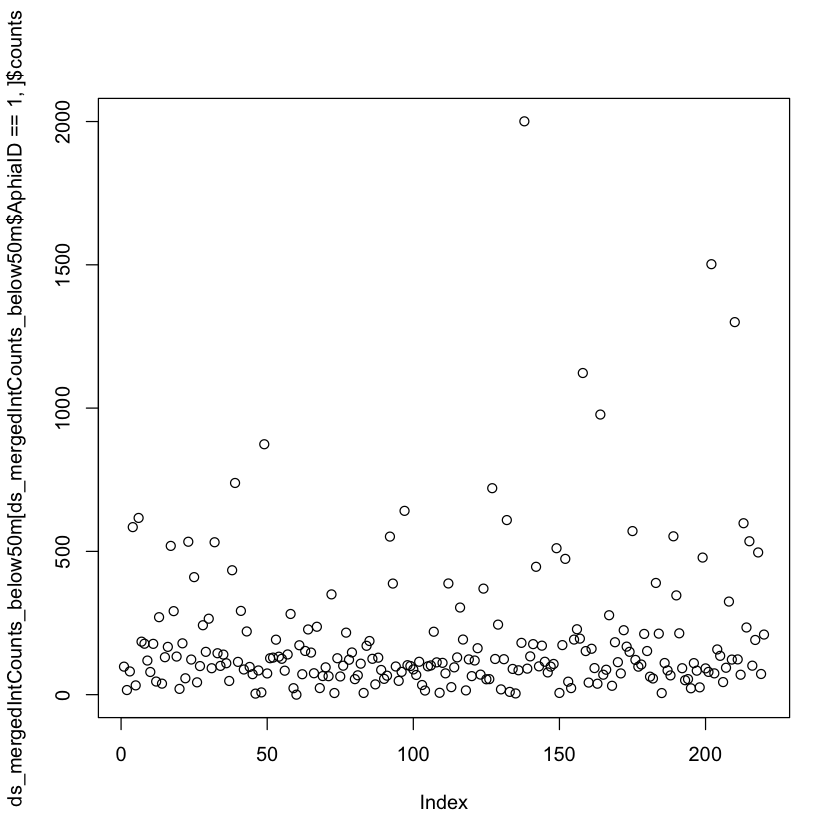

In [50]:
plot(ds_mergedIntCounts_below50m[ds_mergedIntCounts_below50m$AphiaID==1,]$counts)

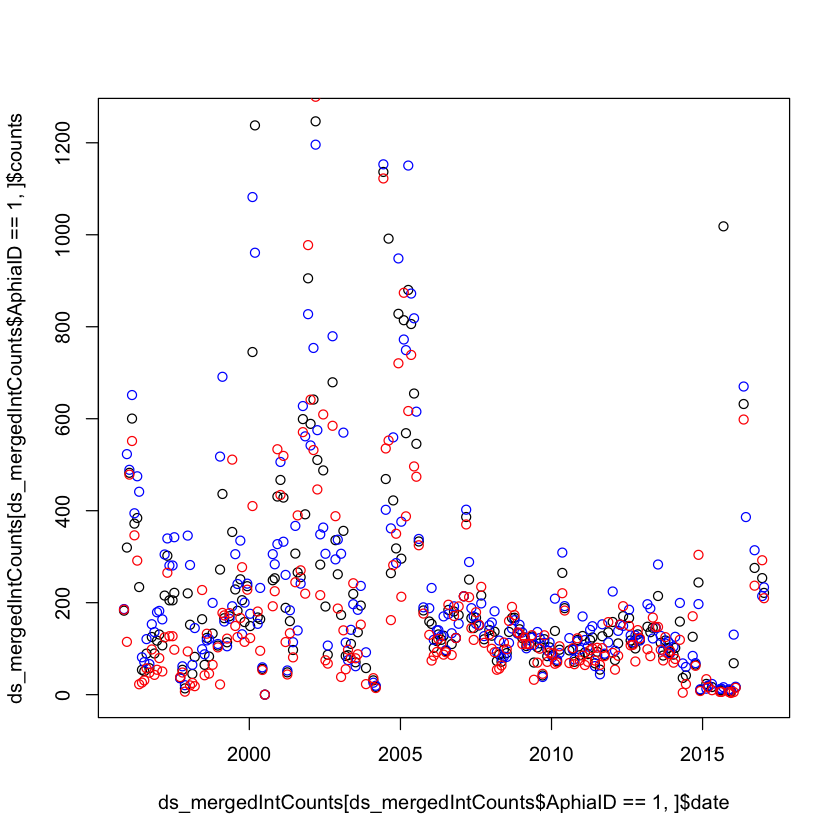

In [51]:
plot(ds_mergedIntCounts[ds_mergedIntCounts$AphiaID==1,]$date, ds_mergedIntCounts[ds_mergedIntCounts$AphiaID==1,]$counts)
points(ds_mergedIntCounts_above50m[ds_mergedIntCounts_above50m$AphiaID==1,]$date, ds_mergedIntCounts_above50m[ds_mergedIntCounts_above50m$AphiaID==1,]$counts, col="blue")
points(ds_mergedIntCounts_below50m[ds_mergedIntCounts_below50m$AphiaID==1,]$date, ds_mergedIntCounts_below50m[ds_mergedIntCounts_below50m$AphiaID==1,]$counts, col="red")

In [64]:
ds1 <- ds_mergedIntCounts[ds_mergedIntCounts$AphiaID==1,] %>% select(date,counts)
ds2 <- ds_mergedIntCounts_above50m[ds_mergedIntCounts_above50m$AphiaID==1,] %>% select(date,counts)
ds3 <- ds_mergedIntCounts_below50m[ds_mergedIntCounts_below50m$AphiaID==1,] %>% select(date,counts)

ds4 <- left_join(ds1,ds2,by="date",suffix=c(".full",".above"))
ds5 <- left_join(ds4,ds3,by="date")

In [74]:
ds5 %>% group_by(date) %>% mutate(mean_counts=sum(c(counts*55/100,counts.above*50/100))) %>% ungroup() %>% slice_max(counts)

date,counts.full,counts.above,counts,mean_counts
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>
2015-09-10 08:50:00,1018.322,16.78559,1823.039,1010.225


In [1]:
library(tidyverse)

# import interpolation functions
source('interpolateData.r')

# Read phytoplankton count data
ds <- read.csv("BCO-DMO/phytoplankton.csv")  #, na.strings=c("nd","?"))

# Fix date, Aphia ID and depth columns
ds$date = parse_date_time(ds$Datetime_UTC, orders="%Y-%m-%d[.]H:M", tz='UTC')
ds$d_7m = as.numeric(ds$d_7m)
ds$d_75m = as.numeric(ds$d_75m)
ds$d_100m = as.numeric(ds$d_100m)
ds$AphiaID = as.integer(ds$AphiaID)

# read annotated and corrected pyhytoplankton data (table with manually corrected names and IDs)
occurrence_corrected <- read.csv("processed/corrected_phyto_names_and_ids.csv", stringsAsFactor=FALSE)

# trim dataframe to relevant columns
AphiaIDcorrected <- data.frame("AphiaID" = as.integer(occurrence_corrected$AphiaID), 
                               "TaxonRank"=as.character(occurrence_corrected$IdentifiedRank),
                               "CorrectedAphiaID"=as.integer(occurrence_corrected$CorrectedAphiaID), 
                               "SpeciesNameCleaned"=occurrence_corrected$SpeciesNameCleaned, 
                               "ScientificName_corrected"=occurrence_corrected$ScientificName_corrected,
                               "FuncGroup"=occurrence_corrected$FuncGroup,
                               "Genus"=occurrence_corrected$Genus, stringsAsFactors=FALSE)


# Filter out duplicates
AphiaIDcorrected_rmdp <- AphiaIDcorrected %>% distinct(AphiaID, ScientificName_corrected, .keep_all = TRUE)

# Merge the original data and the corrected by species name and Aphia ID
ds_phytoMergedCorrected <- merge(ds, AphiaIDcorrected_rmdp, by=c("AphiaID", "SpeciesNameCleaned"), all=TRUE)

# add nanoflagellate data with placeholder AphiaID:
ds_phytoMergedCorrected[ds_phytoMergedCorrected$SpeciesNameCleaned=="nanoflagellates",]$AphiaID <- 1

# replace Aphia IDs from original dataset with corrected annotated IDs, then remove NA Aphia IDs (only identified samples)
ds_FG <- ds_phytoMergedCorrected %>% mutate(AphiaID = coalesce(AphiaID, CorrectedAphiaID)) %>% drop_na(AphiaID)

# extract metadata of unique identified units for later merging with interpolated counts via Aphia ID:
ds_FG_uniqueInfo <- ds_FG  %>% group_by(AphiaID) %>% 
  summarize(TaxonRank=first(TaxonRank, na_rm = TRUE), FuncGroup=first(FuncGroup, na_rm = TRUE), 
            Genus=first(Genus, na_rm = TRUE), ScientificName_corrected=first(ScientificName_corrected, na_rm = TRUE))


# prepare data for interpolation:
ds_phyInt <- rbind(data.frame(val=ds_FG$d_1m, depth=1, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_7m, depth=7, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_15m, depth=15, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_25m, depth=25, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_55m, depth=55, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_75m, depth=75, date=ds_FG$date, AphiaID=ds_FG$AphiaID),
                   data.frame(val=ds_FG$d_100m, depth=100, date=ds_FG$date, AphiaID=ds_FG$AphiaID))


# Missing Data is set to 0 (none observed)
Mesh_phyInt <- pivot_wider(ds_phyInt, names_from = AphiaID, values_from = val, values_fn = sum, values_fill = 0)

# Get unique Aphia IDs to iterate over
phyto_AphiaID = na.omit(as.character(unique(ds_phyInt$AphiaID)))

# Interpolate
getPhytoInterpCounts <- function(depth_from=0, depth_to=100, noofNA=20){
  phyto_temp_store = list()
  
  for (variable in phyto_AphiaID) {
    # interpolation algorithm: oce-rr
    phyto_temp_store[[variable]] <- interpolateData(Mesh_phyInt, variable, depth_from=depth_from, depth_to=depth_to, noofNA=noofNA, int_func='unesco')
    names(phyto_temp_store[[variable]])[1] <- variable
  }
  
  phyto_ds_cleaned <- phyto_temp_store %>% 
    reduce(full_join, by = "date") %>% na.omit()
  
  phyto_ds_cleaned_pivot <- phyto_ds_cleaned %>% 
    pivot_longer(cols=-date, names_to = "AphiaID", values_to = "counts") 
  
  phyto_ds_cleaned_pivot$AphiaID = as.integer(phyto_ds_cleaned_pivot$AphiaID)
  
  ds_mergedIntCounts <- merge(phyto_ds_cleaned_pivot, ds_FG_uniqueInfo, by=c("AphiaID"), all=TRUE) %>% 
    select(date, AphiaID, counts, ScientificName_corrected, Genus, FuncGroup, TaxonRank)
  
  return(ds_mergedIntCounts)    
}

ds_mergedIntCounts <- getPhytoInterpCounts()

str(ds_mergedIntCounts)

# Save interpolated phytoplankton counts
#saveRDS(ds_mergedIntCounts, "data/processed/PhytoplanktonInterpolatedCounts.RDS")

# TODO:
# find where the NAs get generated here!!!
# Somehow there are loads there.. not sure where from.



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Lade nötiges Paket: gsw

Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”
Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”
Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”
Warning message in eval(expr, envir, enclos):
“NAs durch Umwandlung erzeugt”
Warning message in data.frame(AphiaID = as.integer(occurrence_corrected$AphiaID), :
“NAs durch Umwandlung erzeugt”


'data.frame':	145860 obs. of  7 variables:
 $ date                    : POSIXct, format: "1997-07-08 09:24:00" "2015-03-10 09:10:00" ...
 $ AphiaID                 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ counts                  : num  221.5 18.2 97.1 679.2 69.8 ...
 $ ScientificName_corrected: chr  "nanoflagellates" "nanoflagellates" "nanoflagellates" "nanoflagellates" ...
 $ Genus                   : chr  "" "" "" "" ...
 $ FuncGroup               : chr  "Nanoflagellates" "Nanoflagellates" "Nanoflagellates" "Nanoflagellates" ...
 $ TaxonRank               : chr  "Group" "Group" "Group" "Group" ...


In [4]:
which(is.na(ds_mergedIntCounts), arr.ind=TRUE)

row,col


In [20]:
str(which(is.na(ds_FG_uniqueInfo), arr.ind=TRUE))

 int[0 , 1:2] 
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [24]:
head(ds_FG[ds_FG$AphiaID==1,])

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
96432,1,nanoflagellates,61,CAR-061,1,4,5,12,2000,10.499,⋯,443.289,600.000,559.326,2187.450,2000-12-05 10:30:00,Group,NA,nanoflagellates,Nanoflagellates,
96433,1,nanoflagellates,211,CAR-211,1,4,1,4,2014,10.501,⋯,187.200,72.800,93.600,1107.600,2014-04-01 08:59:00,Group,NA,nanoflagellates,Nanoflagellates,
96434,1,nanoflagellates,65,CAR-065,1,4,4,4,2001,10.504,⋯,22.000,41.391,58.254,411.773,2001-04-04 09:45:00,Group,NA,nanoflagellates,Nanoflagellates,
96435,1,nanoflagellates,206,CAR-206,1,4,8,10,2013,10.503,⋯,166.400,166.400,83.200,743.600,2013-10-08 08:55:00,Group,NA,nanoflagellates,Nanoflagellates,
96436,1,nanoflagellates,52,CAR-052,1,4,9,3,2000,10.500,⋯,456.621,93.513,2760.000,5167.210,2000-03-09 09:32:00,Group,NA,nanoflagellates,Nanoflagellates,
96437,1,nanoflagellates,48,CAR-048,2,4,4,11,1999,10.499,⋯,111.099,218.000,73.584,1208.740,1999-11-04 09:18:00,Group,NA,nanoflagellates,Nanoflagellates,


In [22]:
head(ds_FG)

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
1,801,chlorophyte,11,CAR-011,1,4,10,9,1996,10.500,⋯,0,0,0,0,1996-09-10 08:37:00,Phylum,NA,Chlorophyta,Chlorophyte,
2,801,chlorophyte,102,CAR-102,1,4,7,7,2004,10.497,⋯,0,0,0,0,2004-07-07 08:26:00,Phylum,NA,Chlorophyta,Chlorophyte,
3,801,chlorophyte,88,CAR-088,1,4,8,4,2003,10.492,⋯,0,0,0,0,2003-04-08 08:27:00,Phylum,NA,Chlorophyta,Chlorophyte,
4,801,chlorophyte,90,CAR-090,1,4,10,6,2003,10.498,⋯,0,0,0,0,2003-06-10 08:51:00,Phylum,NA,Chlorophyta,Chlorophyte,
5,801,chlorophyte,201,CAR-201,2,4,9,5,2013,10.503,⋯,0,0,0,0,2013-05-09 08:55:00,Phylum,NA,Chlorophyta,Chlorophyte,
6,801,chlorophyte,45,CAR-045,1,4,11,8,1999,10.501,⋯,0,0,0,0,1999-08-11 09:25:00,Phylum,NA,Chlorophyta,Chlorophyte,


In [19]:
# extract metadata of unique identified units for later merging with interpolated counts via Aphia ID:
ds_FG_uniqueInfo <- ds_FG %>% group_by(AphiaID) %>% 
  summarize(TaxonRank=dplyr::first(TaxonRank), FuncGroup=dplyr::first(FuncGroup), 
            Genus=dplyr::first(Genus), ScientificName_corrected=dplyr::first(ScientificName_corrected))

In [17]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS Sonoma 14.6.1

Matrix products: default
BLAS/LAPACK: /Users/aoop/mambaforge/envs/rspatial/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C/UTF-8/C/C/C/C

time zone: Europe/Berlin
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] oce_1.8-2       gsw_1.1-1       lubridate_1.9.3 forcats_1.0.0  
 [5] stringr_1.5.1   dplyr_1.1.4     purrr_1.0.2     readr_2.1.5    
 [9] tidyr_1.3.1     tibble_3.2.1    ggplot2_3.5.1   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] gtable_0.3.5      jsonlite_1.8.8    compiler_4.3.3    crayon_1.5.3     
 [5] Rcpp_1.0.13       tidyselect_1.2.1  IRdisplay_1.1     scales_1.3.0     
 [9] uuid_1.2-1        fastmap_1.2.0     IRkernel_1.3.2    R6_2.5.1         
[13] generics_0.1.3    munsell_0.5.1     pillar_1.9.0      tzdb_0.4.0     

In [28]:
tail(ds_phytoMergedCorrected)


,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
96868,NA,palmelloid colony,169,CAR-169,2,4,11,5,2010,10.501,⋯,0,0,0,0,2010-05-11 08:51:00,Group,NA,palmelloid colony,PalmelloidColony,
96869,NA,palmelloid colony,145,CAR-145,1,4,6,5,2008,10.496,⋯,0,0,0,0,2008-05-06 09:12:00,Group,NA,palmelloid colony,PalmelloidColony,
96870,NA,palmelloid colony,25,CAR-025,2,4,13,11,1997,10.499,⋯,0,0,0,0,1997-11-13 09:41:00,Group,NA,palmelloid colony,PalmelloidColony,
96871,NA,palmelloid colony,44,CAR-044,1,4,15,7,1999,10.499,⋯,0,0,0,0,1999-07-15 09:36:00,Group,NA,palmelloid colony,PalmelloidColony,
96872,NA,palmelloid colony,83,CAR-083,1,4,7,11,2002,10.497,⋯,0,0,0,0,2002-11-07 08:36:00,Group,NA,palmelloid colony,PalmelloidColony,
96873,NA,palmelloid colony,38,CAR-038,1,4,12,1,1999,10.499,⋯,0,0,0,0,1999-01-12 09:30:00,Group,NA,palmelloid colony,PalmelloidColony,


In [ ]:
?merge


In [31]:

# Merge the original data and the corrected by species name and Aphia ID
ds_phytoMergedCorrected <- merge(ds, AphiaIDcorrected_rmdp, by=c("AphiaID", "SpeciesNameCleaned"), all=TRUE)

In [34]:
tail(ds_phytoMergedCorrected)

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
96868,NA,palmelloid colony,169,CAR-169,2,4,11,5,2010,10.501,⋯,0,0,0,0,2010-05-11 08:51:00,Group,NA,palmelloid colony,PalmelloidColony,
96869,NA,palmelloid colony,145,CAR-145,1,4,6,5,2008,10.496,⋯,0,0,0,0,2008-05-06 09:12:00,Group,NA,palmelloid colony,PalmelloidColony,
96870,NA,palmelloid colony,25,CAR-025,2,4,13,11,1997,10.499,⋯,0,0,0,0,1997-11-13 09:41:00,Group,NA,palmelloid colony,PalmelloidColony,
96871,NA,palmelloid colony,44,CAR-044,1,4,15,7,1999,10.499,⋯,0,0,0,0,1999-07-15 09:36:00,Group,NA,palmelloid colony,PalmelloidColony,
96872,NA,palmelloid colony,83,CAR-083,1,4,7,11,2002,10.497,⋯,0,0,0,0,2002-11-07 08:36:00,Group,NA,palmelloid colony,PalmelloidColony,
96873,NA,palmelloid colony,38,CAR-038,1,4,12,1,1999,10.499,⋯,0,0,0,0,1999-01-12 09:30:00,Group,NA,palmelloid colony,PalmelloidColony,


In [36]:
#ds_phytoMergedCorrected[ds_phytoMergedCorrected$SpeciesNameCleaned=="palmelloid colony",]

tail(ds_phytoMergedCorrected %>% arrange(date))

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,⋯,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
96868,NA,Coccolithus hulburtianus,232,CAR-232,1,4,12,1,2017,10.5,⋯,0.0,0,0.0,0.00,2017-01-12 08:17:00,Species,178598,Coccolithus hulburtianus,Haptophyta,Coccolithus
96869,NA,Teleaulax aculeata,232,CAR-232,1,4,12,1,2017,10.5,⋯,0.0,0,0.0,0.00,2017-01-12 08:17:00,Species,106305,Teleaulax acuta,Cryptophyte,Teleaulax
96870,NA,Thalassionema delicatula,232,CAR-232,1,4,12,1,2017,10.5,⋯,0.0,0,0.0,0.33,2017-01-12 08:17:00,Species,14909211,Thalassionema delicatula,Bacillariophyceae,Thalassionema
96871,NA,Thalassionema mediterranea,232,CAR-232,1,4,12,1,2017,10.5,⋯,0.0,0,0.0,0.00,2017-01-12 08:17:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema
96872,NA,nanoflagellates,232,CAR-232,1,4,12,1,2017,10.5,⋯,249.6,182,197.6,1508.00,2017-01-12 08:17:00,Group,NA,nanoflagellates,Nanoflagellates,
96873,NA,palmelloid colony,232,CAR-232,1,4,12,1,2017,10.5,⋯,0.0,0,0.0,0.00,2017-01-12 08:17:00,Group,NA,palmelloid colony,PalmelloidColony,


In [38]:
tail(ds)

,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,Longitude,Time_start_local,⋯,d_1m,d_7m,d_15m,d_25m,d_35m,d_55m,d_75m,d_100m,Total_sum,date
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
96836,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96837,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96838,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96839,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00
96840,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.66,0,0,0.04,0,0.01,0.7,2017-01-12 08:17:00
96841,232,CAR-232,1,4,12,1,2017,10.5,-64.66,04:17,⋯,0,0,0.00,0,0,0.00,0,0.00,0.0,2017-01-12 08:17:00


In [70]:

ds_phytoMergedCorrected <- merge(ds, AphiaIDcorrected_rmdp, by.x="AphiaID", by.y="SpeciesNameCleaned", all=TRUE)


#ds_phytoMergedCorrected <- ds %>% left_join(AphiaIDcorrected_rmdp, by=c("AphiaID","SpeciesNameCleaned"))

In [78]:

ds_phytoMergedCorrected <- merge(ds, AphiaIDcorrected_rmdp, by=c("AphiaID", "SpeciesNameCleaned"), all=TRUE)

In [79]:
str(which(is.na(ds_phytoMergedCorrected), arr.ind=TRUE))

 int [1:121496, 1:2] 95702 95703 95704 95705 95706 95707 95708 95709 95710 95711 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [80]:
#options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
head(ds_phytoMergedCorrected)

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,Longitude,Time_start_local,Time_end_local,Datetime_local,Datetime_UTC,SpeciesNameOriginal,ScientificName_accepted,d_1m,d_7m,d_15m,d_25m,d_35m,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
1,801,chlorophyte,11,CAR-011,1,4,10,9,1996,10.500,-64.660,04:37,05:07,1996-09-10T04:37,1996-09-10T08:37,clorofita,Chlorophyta,0,0,0,0,0,0,0,0,0,1996-09-10 08:37:00,Phylum,NA,Chlorophyta,Chlorophyte,
2,801,chlorophyte,102,CAR-102,1,4,7,7,2004,10.497,-64.668,04:26,04:51,2004-07-07T04:26,2004-07-07T08:26,Chlorophyte,Chlorophyta,0,0,0,0,0,0,0,0,0,2004-07-07 08:26:00,Phylum,NA,Chlorophyta,Chlorophyte,
3,801,chlorophyte,88,CAR-088,1,4,8,4,2003,10.492,-64.673,04:27,04:51,2003-04-08T04:27,2003-04-08T08:27,clorofita,Chlorophyta,0,0,0,0,0,0,0,0,0,2003-04-08 08:27:00,Phylum,NA,Chlorophyta,Chlorophyte,
4,801,chlorophyte,90,CAR-090,1,4,10,6,2003,10.498,-64.668,04:51,05:19,2003-06-10T04:51,2003-06-10T08:51,clorofita,Chlorophyta,0,0,0,0,0,0,0,0,0,2003-06-10 08:51:00,Phylum,NA,Chlorophyta,Chlorophyte,
5,801,chlorophyte,201,CAR-201,2,4,9,5,2013,10.503,-64.679,04:25,04:49,2013-05-09T04:25,2013-05-09T08:55,clorofita,Chlorophyta,0,0,0,0,0,0,0,0,0,2013-05-09 08:55:00,Phylum,NA,Chlorophyta,Chlorophyte,
6,801,chlorophyte,45,CAR-045,1,4,11,8,1999,10.501,-64.666,05:25,05:58,1999-08-11T05:25,1999-08-11T09:25,Chlorophyte,Chlorophyta,0,0,0,0,0,0,0,0,0,1999-08-11 09:25:00,Phylum,NA,Chlorophyta,Chlorophyte,


In [84]:
head(ds_phytoMergedCorrected[ds_phytoMergedCorrected$SpeciesNameCleaned=="Thalassionema mediterranea",])

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,Longitude,Time_start_local,Time_end_local,Datetime_local,Datetime_UTC,SpeciesNameOriginal,ScientificName_accepted,d_1m,d_7m,d_15m,d_25m,d_35m,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus
,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>
96258,NA,Thalassionema mediterranea,215,CAR-215,1,4,7,10,2014,10.509,-64.677,04:21,04:44,2014-10-07T04:21,2014-10-07T08:51,Thalasionema mediterranea,? Thalassionema mediterranea,0.00,0.00,0,0.00,0.00,0,0,0,0.00,2014-10-07 08:51:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema
96259,NA,Thalassionema mediterranea,207,CAR-207,3,4,13,11,2013,10.507,-64.673,04:21,04:43,2013-11-13T04:21,2013-11-13T08:51,Thalasionema mediterranea,? Thalassionema mediterranea,0.01,0.00,0,0.03,0.01,0,0,0,0.05,2013-11-13 08:51:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema
96260,NA,Thalassionema mediterranea,197,CAR-197,1,4,8,11,2012,10.497,-64.670,04:49,05:14,2012-11-08T04:49,2012-11-08T09:19,Thalasionema mediterranea,? Thalassionema mediterranea,0.02,0.00,0,0.00,0.00,0,0,0,0.02,2012-11-08 09:19:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema
96261,NA,Thalassionema mediterranea,182,CAR-182,1,4,7,7,2011,10.501,-64.665,04:27,04:49,2011-07-07T04:27,2011-07-07T08:57,Thalasionema mediterranea,? Thalassionema mediterranea,0.02,0.00,0,0.00,0.00,0,0,0,0.02,2011-07-07 08:57:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema
96262,NA,Thalassionema mediterranea,193,CAR-193,1,4,26,7,2012,10.498,-64.681,04:32,04:59,2012-07-26T04:32,2012-07-26T09:02,Thalasionema mediterranea,? Thalassionema mediterranea,0.02,0.01,0,0.00,0.00,0,0,0,0.03,2012-07-26 09:02:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema
96263,NA,Thalassionema mediterranea,223,CAR-223,1,4,10,9,2015,10.507,-64.668,04:20,04:42,2015-09-10T04:20,2015-09-10T08:50,Thalasionema mediterranea,? Thalassionema mediterranea,0.00,0.00,0,0.00,0.00,0,0,0,0.00,2015-09-10 08:50:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema


In [83]:
head(ds[ds$SpeciesNameCleaned=="Thalassionema mediterranea",])

,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,Longitude,Time_start_local,Time_end_local,Datetime_local,Datetime_UTC,SpeciesNameOriginal,SpeciesNameCleaned,ScientificName_accepted,AphiaID,d_1m,d_7m,d_15m,d_25m,d_35m,d_55m,d_75m,d_100m,Total_sum,date
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
11912,44,CAR-044,1,4,15,7,1999,10.499,-64.669,05:36,06:04,1999-07-15T05:36,1999-07-15T09:36,Thalassionema mediterraneum,Thalassionema mediterranea,? Thalassionema mediterranea,NA,0,0,0,0,0,0,0,0,0,1999-07-15 09:36:00
12244,45,CAR-045,1,4,11,8,1999,10.501,-64.666,05:25,05:58,1999-08-11T05:25,1999-08-11T09:25,Thalassionema mediteraneum,Thalassionema mediterranea,? Thalassionema mediterranea,NA,0,0,0,0,0,0,0,0,0,1999-08-11 09:25:00
12578,46,CAR-046,1,4,14,9,1999,10.497,-64.670,06:05,06:40,1999-09-14T06:05,1999-09-14T10:05,Thalassionema mediteraneum,Thalassionema mediterranea,? Thalassionema mediterranea,NA,0,0,0,0,0,0,0,0,0,1999-09-14 10:05:00
13922,50,CAR-050,1,4,11,1,2000,10.499,-64.671,05:35,06:05,2000-01-11T05:35,2000-01-11T09:35,Thalassionema mediteraneum,Thalassionema mediterranea,? Thalassionema mediterranea,NA,0,0,0,0,0,0,0,0,0,2000-01-11 09:35:00
14260,51,CAR-051,1,4,8,2,2000,10.496,-64.670,05:30,05:59,2000-02-08T05:30,2000-02-08T09:30,Thalassionema mediteraneum,Thalassionema mediterranea,? Thalassionema mediterranea,NA,0,0,0,0,0,0,0,0,0,2000-02-08 09:30:00
14596,52,CAR-052,1,4,9,3,2000,10.500,-64.668,05:32,06:00,2000-03-09T05:32,2000-03-09T09:32,Thalassionema mediteraneum,Thalassionema mediterranea,? Thalassionema mediterranea,NA,0,0,0,0,0,0,0,0,0,2000-03-09 09:32:00


In [85]:
head(AphiaIDcorrected_rmdp[AphiaIDcorrected_rmdp$SpeciesNameCleaned=="Thalassionema mediterranea",])

,AphiaID,TaxonRank,CorrectedAphiaID,SpeciesNameCleaned,ScientificName_corrected,FuncGroup,Genus
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
5,NA,Species,14909222,Thalassionema mediterranea,Thalassionema mediterranea,Bacillariophyceae,Thalassionema


In [86]:
# replace Aphia IDs from original dataset with corrected annotated IDs, then remove NA Aphia IDs (only identified samples)
ds_FG <- ds_phytoMergedCorrected %>% mutate(AphiaID2 = coalesce(AphiaID, CorrectedAphiaID)) %>% drop_na(AphiaID2)


In [88]:
tail(ds_FG)

,AphiaID,SpeciesNameCleaned,Cruise,Cruise_ID_2,Leg,Cast,Day_local,Month_local,Year_local,Latitude,Longitude,Time_start_local,Time_end_local,Datetime_local,Datetime_UTC,SpeciesNameOriginal,ScientificName_accepted,d_1m,d_7m,d_15m,d_25m,d_35m,d_55m,d_75m,d_100m,Total_sum,date,TaxonRank,CorrectedAphiaID,ScientificName_corrected,FuncGroup,Genus,AphiaID2
,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
96426,NA,Thalassionema mediterranea,211,CAR-211,1,4,1,4,2014,10.501,-64.671,04:29,04:54,2014-04-01T04:29,2014-04-01T08:59,Thalasionema mediterranea,? Thalassionema mediterranea,0,0,0,0,0,0,0,0,0,2014-04-01 08:59:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema,14909222
96427,NA,Thalassionema mediterranea,214,CAR-214,1,4,3,9,2014,10.497,-64.674,04:27,04:53,2014-09-03T04:27,2014-09-03T08:57,Thalasionema mediterranea,? Thalassionema mediterranea,0,0,0,0,0,0,0,0,0,2014-09-03 08:57:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema,14909222
96428,NA,Thalassionema mediterranea,79,CAR-079,1,4,12,6,2002,10.499,-64.668,06:16,06:43,2002-06-12T06:16,2002-06-12T10:16,Thalassionema mediteraneum,? Thalassionema mediterranea,0,0,0,0,0,0,0,0,0,2002-06-12 10:16:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema,14909222
96429,NA,Thalassionema mediterranea,72,CAR-072,1,4,6,11,2001,10.499,-64.667,05:52,06:21,2001-11-06T05:52,2001-11-06T09:52,Thalassionema mediterraneum,? Thalassionema mediterranea,0,0,0,0,0,0,0,0,0,2001-11-06 09:52:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema,14909222
96430,NA,Thalassionema mediterranea,218,CAR-218,1,4,15,2,2015,10.500,-64.668,04:19,04:48,2015-02-15T04:19,2015-02-15T08:49,Thalasionema mediterranea,? Thalassionema mediterranea,0,0,0,0,0,0,0,0,0,2015-02-15 08:49:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema,14909222
96431,NA,Thalassionema mediterranea,75,CAR-075,1,4,14,2,2002,10.501,-64.669,06:30,07:03,2002-02-14T06:30,2002-02-14T10:30,Thalassionema mediterraneum,? Thalassionema mediterranea,0,0,0,0,0,0,0,0,0,2002-02-14 10:30:00,Species,14909222,Thalassionema mediterranea,Bacillariophyceae,Thalassionema,14909222


In [91]:
tail(which(is.na(ds_FG), arr.ind=TRUE))

,row,col
"[120602,]",89129,32
"[120603,]",89130,32
"[120604,]",89131,32
"[120605,]",89132,32
"[120606,]",89133,32
"[120607,]",91636,32


In [92]:
which(is.na(ds_FG), arr.ind=TRUE)[120607,]

row   col 
91636    32

In [93]:
class(ds_FG)

[1] "data.frame"

In [94]:
str(ds_mergedIntCounts)


'data.frame':	145860 obs. of  7 variables:
 $ date                    : POSIXct, format: "1997-07-08 09:24:00" "2015-03-10 09:10:00" ...
 $ AphiaID                 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ counts                  : num  221.5 18.2 97.1 679.2 69.8 ...
 $ ScientificName_corrected: chr  "nanoflagellates" "nanoflagellates" "nanoflagellates" "nanoflagellates" ...
 $ Genus                   : chr  "" "" "" "" ...
 $ FuncGroup               : chr  "Nanoflagellates" "Nanoflagellates" "Nanoflagellates" "Nanoflagellates" ...
 $ TaxonRank               : chr  "Group" "Group" "Group" "Group" ...


In [95]:
which(is.na(ds_mergedIntCounts), arr.ind=TRUE)

row,col


In [96]:
ds_mergedIntCounts[39381,]

,date,AphiaID,counts,ScientificName_corrected,Genus,FuncGroup,TaxonRank
,<dttm>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
39381,2008-05-06 09:12:00,115057,0,Haptophyta,,Haptophyta,Phylum


In [97]:
ds_mergedIntCounts[43088,]

,date,AphiaID,counts,ScientificName_corrected,Genus,FuncGroup,TaxonRank
,<dttm>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
43088,2013-08-13 08:53:00,146537,0,Cyanobacteria,,Cyanobacteria,Phylum


In [98]:
which(is.na(phyto_AphiaID), arr.ind=TRUE)

integer(0)

In [99]:
str(phyto_AphiaID)


 chr [1:663] "801" "17657" "106283" "106285" "106289" "106314" "109421" ...


In [100]:
str(which(is.na(Mesh_phyInt), arr.ind=TRUE))


 int [1:1145, 1:2] 1113 1334 1113 1334 1113 1334 1113 1334 1113 1334 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [101]:
str(which(is.na(ds_FG_uniqueInfo), arr.ind=TRUE))


 int[0 , 1:2] 
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [102]:
str(which(is.na(ds_phytoMergedCorrected), arr.ind=TRUE))


 int [1:121496, 1:2] 95702 95703 95704 95705 95706 95707 95708 95709 95710 95711 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [103]:
str(which(is.na(AphiaIDcorrected_rmdp), arr.ind=TRUE))

 int [1:573, 1:2] 1 2 3 4 5 6 7 6 7 8 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [104]:
str(ds_phytoMergedCorrected)


'data.frame':	96873 obs. of  32 variables:
 $ AphiaID                 : int  801 801 801 801 801 801 801 801 801 801 ...
 $ SpeciesNameCleaned      : chr  "chlorophyte" "chlorophyte" "chlorophyte" "chlorophyte" ...
 $ Cruise                  : int  11 102 88 90 201 45 33 229 112 82 ...
 $ Cruise_ID_2             : chr  "CAR-011" "CAR-102" "CAR-088" "CAR-090" ...
 $ Leg                     : int  1 1 1 1 2 1 1 1 1 1 ...
 $ Cast                    : int  4 4 4 4 4 4 4 0 4 4 ...
 $ Day_local               : int  10 7 8 10 9 11 5 7 10 3 ...
 $ Month_local             : int  9 7 4 6 5 8 8 6 5 10 ...
 $ Year_local              : int  1996 2004 2003 2003 2013 1999 1998 2016 2005 2002 ...
 $ Latitude                : num  10.5 10.5 10.5 10.5 10.5 ...
 $ Longitude               : num  -64.7 -64.7 -64.7 -64.7 -64.7 ...
 $ Time_start_local        : chr  "04:37" "04:26" "04:27" "04:51" ...
 $ Time_end_local          : chr  "05:07" "04:51" "04:51" "05:19" ...
 $ Datetime_local          : chr  "1996

In [105]:
str(which(is.na(ds_phytoMergedCorrected), arr.ind=TRUE))


 int [1:121496, 1:2] 95702 95703 95704 95705 95706 95707 95708 95709 95710 95711 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [2]:
str(which(is.na(ds_FG), arr.ind=TRUE))

 int [1:120101, 1:2] 96604 8 233 490 537 547 619 845 1285 1483 ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [107]:
head(ds_FG[which(is.na(ds_FG), arr.ind=TRUE)])

[1] NA NA NA NA NA NA

In [3]:
str(ds_FG)

'data.frame':	96652 obs. of  32 variables:
 $ AphiaID                 : num  801 801 801 801 801 801 801 801 801 801 ...
 $ SpeciesNameCleaned      : chr  "chlorophyte" "chlorophyte" "chlorophyte" "chlorophyte" ...
 $ Cruise                  : int  11 102 88 90 201 45 33 229 112 82 ...
 $ Cruise_ID_2             : chr  "CAR-011" "CAR-102" "CAR-088" "CAR-090" ...
 $ Leg                     : int  1 1 1 1 2 1 1 1 1 1 ...
 $ Cast                    : int  4 4 4 4 4 4 4 0 4 4 ...
 $ Day_local               : int  10 7 8 10 9 11 5 7 10 3 ...
 $ Month_local             : int  9 7 4 6 5 8 8 6 5 10 ...
 $ Year_local              : int  1996 2004 2003 2003 2013 1999 1998 2016 2005 2002 ...
 $ Latitude                : num  10.5 10.5 10.5 10.5 10.5 ...
 $ Longitude               : num  -64.7 -64.7 -64.7 -64.7 -64.7 ...
 $ Time_start_local        : chr  "04:37" "04:26" "04:27" "04:51" ...
 $ Time_end_local          : chr  "05:07" "04:51" "04:51" "05:19" ...
 $ Datetime_local          : chr  "1996

In [4]:
str(ds_FG_uniqueInfo)

tibble [663 × 5] (S3: tbl_df/tbl/data.frame)
 $ AphiaID                 : num [1:663] 1 801 17657 106283 106285 ...
 $ TaxonRank               : chr [1:663] "Group" "Phylum" "Genus" "Genus" ...
 $ FuncGroup               : chr [1:663] "Nanoflagellates" "Chlorophyte" "Others" "Cryptophyte" ...
 $ Genus                   : chr [1:663] "" "" "Eutreptiella" "Plagioselmis" ...
 $ ScientificName_corrected: chr [1:663] "nanoflagellates" "Chlorophyta" "Eutreptiella sp." "Plagioselmis sp." ...


In [5]:
str(which(is.na(ds_FG_uniqueInfo), arr.ind=TRUE))

 int[0 , 1:2] 
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [6]:
ds_FG_uniqueInfo[180,]


AphiaID,TaxonRank,FuncGroup,Genus,ScientificName_corrected
<dbl>,<chr>,<chr>,<chr>,<chr>
115057,Phylum,Haptophyta,,Haptophyta


In [8]:
str(which(is.na(ds_FG_uniqueInfo), arr.ind=TRUE))

 int[0 , 1:2] 
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"


In [3]:
tail(ds_mergedIntCounts)

,date,AphiaID,counts,ScientificName_corrected,Genus,FuncGroup,TaxonRank
,<dttm>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
145855,2015-04-24 09:00:00,14909222,0,Thalassionema mediterranea,Thalassionema,Bacillariophyceae,Species
145856,2005-06-14 09:06:00,14909222,0,Thalassionema mediterranea,Thalassionema,Bacillariophyceae,Species
145857,2001-04-04 09:45:00,14909222,0,Thalassionema mediterranea,Thalassionema,Bacillariophyceae,Species
145858,2011-06-09 09:06:00,14909222,0,Thalassionema mediterranea,Thalassionema,Bacillariophyceae,Species
145859,1996-03-13 08:44:00,14909222,0,Thalassionema mediterranea,Thalassionema,Bacillariophyceae,Species
145860,2007-04-10 09:15:00,14909222,0,Thalassionema mediterranea,Thalassionema,Bacillariophyceae,Species


In [4]:
str(which(is.na(ds_mergedIntCounts), arr.ind=TRUE))

 int[0 , 1:2] 
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:2] "row" "col"
